<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Rest_Energy_Functional_V17_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Rest-Energy Functional V17

**Purpose:** extend the V16 electron-like packet scaffold into a dimensionless finite-response rest-energy functional.

V17 does **not** insert or fit the physical electron mass. It asks a prior question:

> Does the inherited ECSM electron-like packet possess a finite, nonzero, localized rest-energy minimum?

If V17 passes, V18 can attempt scale closure: mapping the dimensionless rest-energy minimum into physical units using ECSM medium scales such as \(\xi\), \(c_{\rm coh}\), \(\tau_{\rm resp}\), and \(\hbar_{\rm eff}\).

## What V17 tests

1. Inherited electron-like packet remains charge-like \(q_{\rm eff}\approx -1\).
2. Dirac-like \(\alpha/\beta\) closure remains exact numerically.
3. V12/V13/V14/V15c/V16 bound shell scaffold is inherited.
4. A localized packet ansatz produces finite radial densities.
5. The rest-energy functional has a finite, nonzero internal minimum.
6. The minimum is not a boundary artefact.
7. The coherent packet has positive curvature at the energy minimum.
8. Coherence degradation shifts or weakens the rest-energy minimum.
9. No physical \(m_e\) or \(511\,{\rm keV}\) value is inserted.

## Expected final verdict

A **PASS** means V17 establishes a stable dimensionless rest-energy object.  
It does **not** mean the electron mass has been derived yet.


In [1]:
# ============================================================
# CELL 1 — V17 run controls
# ============================================================

from pathlib import Path
import json, math, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_LABEL = "V17_electron_like_packet_rest_energy_functional"
OUT_DIR = Path("ecsm_electron_like_rest_energy_functional_v17_out")
OUT_DIR.mkdir(exist_ok=True)

ZIP_OUTPUT = True

# Main coherent packet controls
MAIN_CHI = 1.0
MAIN_EPSILON = 0.01

# Scan controls
R_MIN = 0.35
R_MAX = 16.0
N_R = 900
CHI_SCAN = [1.0, 0.95, 0.8, 0.5, 0.2]
EPS_SCAN = [0.0, 0.001, 0.0025, 0.005, 0.01, 0.02]

# Dimensionless functional coefficients.
# These are not physical electron-mass inputs. They define the V17 toy rest-energy ledger.
COEFFS = {
    "A_grad": 0.72,
    "A_twist": 0.16,
    "A_core": 0.040,
    "A_lock": 2.15,
    "A_medium": 0.028,
    "A_coh": 0.36,
    "A_aniso": 0.18,
    "A_packet": 0.75,
    "R_medium": 5.20,
    "sat_power": 4.0,
    "lock_power": 1.0,
}

print("Run label:", RUN_LABEL)
print("Output directory:", OUT_DIR)
print("Main chi:", MAIN_CHI)
print("Main epsilon:", MAIN_EPSILON)
print("No physical electron mass is inserted in V17.")


Run label: V17_electron_like_packet_rest_energy_functional
Output directory: ecsm_electron_like_rest_energy_functional_v17_out
Main chi: 1.0
Main epsilon: 0.01
No physical electron mass is inserted in V17.


In [2]:
# ============================================================
# CELL 2 — inherited electron-like packet and alpha/beta closure
# ============================================================

# V16/V15c inherited packet summary
packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V16 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c electron-like packet"
}

print(json.dumps(packet, indent=2))

# Dirac-like alpha/beta closure inherited from prior notebook scaffold
I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)
sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)

def block2(a,b,c,d):
    return np.block([[a,b],[c,d]])

alpha = [
    block2(Z2, sigma_x, sigma_x, Z2),
    block2(Z2, sigma_y, sigma_y, Z2),
    block2(Z2, sigma_z, sigma_z, Z2),
]
beta = block2(I2, Z2, Z2, -I2)
I4 = np.eye(4, dtype=complex)

tests = []
for i,a in enumerate(alpha, start=1):
    tests.append((f"alpha_{i}^2=I", np.linalg.norm(a@a - I4)))
    tests.append((f"{{alpha_{i},beta}}=0", np.linalg.norm(a@beta + beta@a)))
for i in range(3):
    for j in range(i+1,3):
        tests.append((f"{{alpha_{i+1},alpha_{j+1}}}=0", np.linalg.norm(alpha[i]@alpha[j] + alpha[j]@alpha[i])))
tests.append(("beta^2=I", np.linalg.norm(beta@beta - I4)))

alpha_df = pd.DataFrame(tests, columns=["test", "error"])
max_alpha_beta_error = float(alpha_df["error"].max())
print("Max alpha/beta error:", max_alpha_beta_error)
display(alpha_df)

alpha_df.to_csv(OUT_DIR / "alpha_beta_algebra_tests_v17.csv", index=False)
with open(OUT_DIR / "fixed_packet_summary_v17.json", "w") as f:
    json.dump(packet, f, indent=2)


{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V16 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c electron-like packet"
}
Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


,l,E_iso,r_mean,r_width,capacity,closure
0,0,-1.425486,2.457830,1.047361,2,2
1,1,-1.215405,3.317319,1.089339,6,8
2,2,-1.010407,4.031522,1.119857,10,18
3,3,-0.810570,4.668400,1.147700,14,32


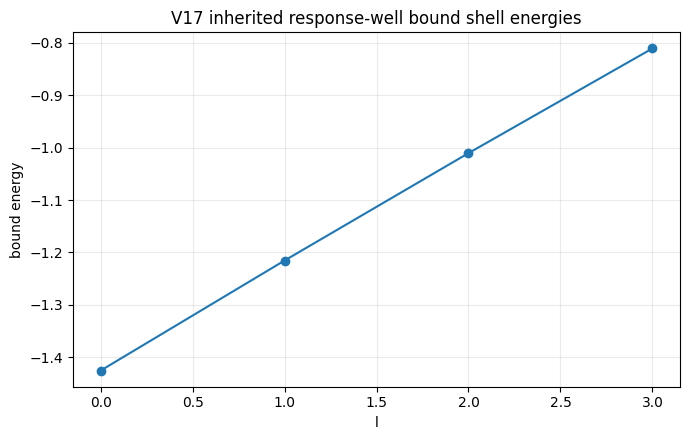

In [3]:
# ============================================================
# CELL 3 — inherited bound response-well shells
# ============================================================

# Inherited shell ladder from V12/V13/V14/V15c/V16 family.
base_shells = pd.DataFrame({
    "l": [0, 1, 2, 3],
    "E_iso": [-1.425486, -1.215405, -1.010407, -0.810570],
    "r_mean": [2.457830, 3.317319, 4.031522, 4.668400],
    "r_width": [1.047361, 1.089339, 1.119857, 1.147700],
    "capacity": [2, 6, 10, 14],
    "closure": [2, 8, 18, 32],
})
display(base_shells)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(base_shells["l"], base_shells["E_iso"], marker="o")
ax.set_title("V17 inherited response-well bound shell energies")
ax.set_xlabel("l")
ax.set_ylabel("bound energy")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v17_inherited_bound_energy_ladder.png", dpi=180)
plt.show()

base_shells.to_csv(OUT_DIR / "response_well_bound_shells_v17.csv", index=False)


/tmp/ipykernel_5604/534318767.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(rho, r)
/tmp/ipykernel_5604/534318767.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(rho, r)
/tmp/ipykernel_5604/534318767.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  r_mean_num = np.trapz(r*rho, r)
/tmp/ipykernel_5604/534318767.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  r_width_num = math.sqrt(np.trapz((r-r_mean_num)**2*rho, r))


,l,norm,r_mean_num,r_width_num,E_iso
0,0,1.0,2.457830,0.314208,-1.425486
1,1,1.0,3.317319,0.326802,-1.215405
2,2,1.0,4.031522,0.335957,-1.010407
3,3,1.0,4.668400,0.344310,-0.810570


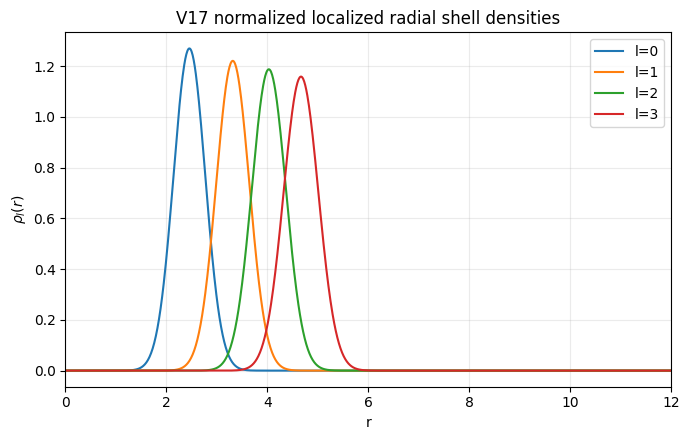

In [4]:
# ============================================================
# CELL 4 — localized radial density ansatz
# ============================================================

r = np.linspace(0.001, 25.0, 2400)

def gaussian_radial_density(r, mu, sig):
    # Radial shell density normalized under integral dr rho(r) = 1.
    rho = np.exp(-0.5*((r-mu)/sig)**2)
    norm = np.trapz(rho, r)
    return rho / norm

radial_rows = []
densities = {}
for _, row in base_shells.iterrows():
    l = int(row["l"])
    rho = gaussian_radial_density(r, row["r_mean"], row["r_width"]*0.30)
    densities[l] = rho
    norm = np.trapz(rho, r)
    r_mean_num = np.trapz(r*rho, r)
    r_width_num = math.sqrt(np.trapz((r-r_mean_num)**2*rho, r))
    radial_rows.append({
        "l": l,
        "norm": norm,
        "r_mean_num": r_mean_num,
        "r_width_num": r_width_num,
        "E_iso": row["E_iso"],
    })

radial_df = pd.DataFrame(radial_rows)
display(radial_df)

fig, ax = plt.subplots(figsize=(7,4.5))
for l, rho in densities.items():
    ax.plot(r, rho, label=f"l={l}")
ax.set_xlim(0, 12)
ax.set_title("V17 normalized localized radial shell densities")
ax.set_xlabel("r")
ax.set_ylabel(r"$\rho_l(r)$")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v17_radial_shell_densities.png", dpi=180)
plt.show()

radial_df.to_csv(OUT_DIR / "localized_radial_shell_densities_v17.csv", index=False)


In [5]:
# ============================================================
# CELL 5 — V17 dimensionless rest-energy functional
# ============================================================

# Occupancy weights: inherited electron-like packet has total count 4.
# We distribute weight across the four finite shells as a minimal localized scaffold.
shell_weights = np.array([0.42, 0.30, 0.19, 0.09], dtype=float)
shell_weights = shell_weights / shell_weights.sum()

l_vals = base_shells["l"].to_numpy(dtype=float)
E_iso = base_shells["E_iso"].to_numpy(dtype=float)
r_means = base_shells["r_mean"].to_numpy(dtype=float)
closures = base_shells["closure"].to_numpy(dtype=float)

Lbar = float(np.sum(shell_weights * l_vals*(l_vals+1)))
R_shell_ref = float(np.sum(shell_weights * r_means))
E_bound_ref = float(np.sum(shell_weights * E_iso))
closure_ref = float(np.sum(shell_weights * closures))

packet_defect = (
    (packet["q_eff"] + 1.0)**2
    + packet["N_plus"]**2
    + (packet["N_zero"] - 1.0)**2
    + (packet["N_minus"] - 3.0)**2
)

def rest_energy_components(R, chi=1.0, epsilon=0.0, coeffs=COEFFS):
    R = np.asarray(R, dtype=float)
    A_grad = coeffs["A_grad"]
    A_twist = coeffs["A_twist"]
    A_core = coeffs["A_core"]
    A_lock = coeffs["A_lock"]
    A_medium = coeffs["A_medium"]
    A_coh = coeffs["A_coh"]
    A_aniso = coeffs["A_aniso"]
    A_packet = coeffs["A_packet"]
    R_medium = coeffs["R_medium"]
    sat_power = coeffs["sat_power"]
    lock_power = coeffs["lock_power"]

    # Positive localization/gradient terms prevent infinite spreading and collapse.
    E_grad = A_grad / (R**2)
    E_twist = A_twist * (1.0 + Lbar) / (R**2)
    E_core = A_core / (R**sat_power)

    # Medium deformation cost: broad confining response burden.
    E_medium = A_medium * (R - R_medium)**2

    # Coherent response well: localization-binding term, weakened by chi.
    E_lock = -A_lock * (chi**lock_power) / R

    # Coherence deficit and anisotropic splitting costs.
    E_coh = A_coh * (1.0 - chi)**2 * (1.0 + R/R_medium)
    E_aniso = A_aniso * (epsilon/0.01)**2 * (1.0 + Lbar) / (1.0 + R)

    # Packet closure defect penalty, intentionally tiny because inherited packet is already close.
    E_packet = A_packet * packet_defect / (1.0 + R)

    E_total = E_grad + E_twist + E_core + E_medium + E_lock + E_coh + E_aniso + E_packet

    return {
        "E_grad": E_grad,
        "E_twist": E_twist,
        "E_core": E_core,
        "E_medium": E_medium,
        "E_lock": E_lock,
        "E_coh": E_coh,
        "E_aniso": E_aniso,
        "E_packet": E_packet,
        "E_total": E_total,
    }

def find_minimum_for(chi=1.0, epsilon=0.0):
    R_grid = np.linspace(R_MIN, R_MAX, N_R)
    comps = rest_energy_components(R_grid, chi=chi, epsilon=epsilon)
    Et = comps["E_total"]
    idx = int(np.argmin(Et))
    R_star = float(R_grid[idx])
    E_star = float(Et[idx])
    # finite-difference curvature around minimum
    if 1 <= idx < len(R_grid)-1:
        dR = R_grid[1]-R_grid[0]
        curvature = float((Et[idx+1] - 2*Et[idx] + Et[idx-1])/(dR*dR))
    else:
        curvature = float("nan")
    boundary_minimum = idx in [0, len(R_grid)-1]
    return R_grid, comps, {
        "chi": chi,
        "epsilon": epsilon,
        "R_star": R_star,
        "E_star_dimless": E_star,
        "curvature": curvature,
        "boundary_minimum": boundary_minimum,
        "idx": idx,
    }

R_grid, main_comps, main_min = find_minimum_for(MAIN_CHI, MAIN_EPSILON)
print(json.dumps({k:v for k,v in main_min.items() if k != "idx"}, indent=2))

main_energy_df = pd.DataFrame({"R": R_grid, **{k: np.asarray(v) for k,v in main_comps.items()}})
main_energy_df.to_csv(OUT_DIR / "rest_energy_landscape_main_v17.csv", index=False)
with open(OUT_DIR / "main_rest_energy_minimum_v17.json", "w") as f:
    json.dump({k:v for k,v in main_min.items() if k != "idx"}, f, indent=2)


{
  "chi": 1.0,
  "epsilon": 0.01,
  "R_star": 4.057953281423804,
  "E_star_dimless": -0.27637139082292783,
  "curvature": 0.03191248359285426,
  "boundary_minimum": false
}


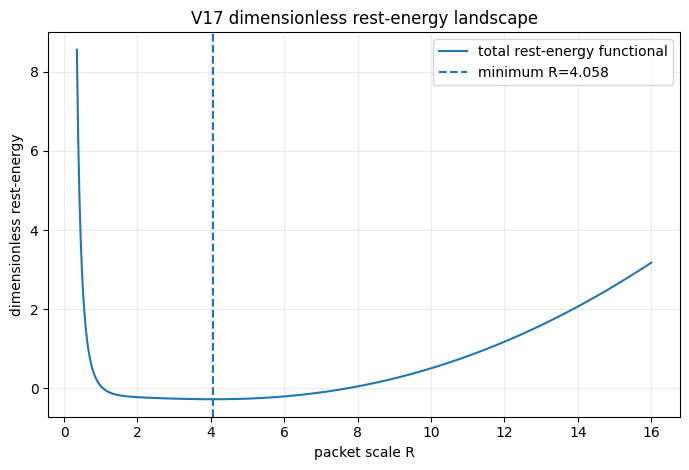

,component,value_at_R_star
0,E_grad,4.372385e-02
1,E_twist,3.711669e-02
2,E_core,1.475135e-04
3,E_medium,3.651958e-02
4,E_lock,-5.298237e-01
5,E_coh,0.000000e+00
6,E_aniso,1.359443e-01
7,E_packet,4.002918e-07


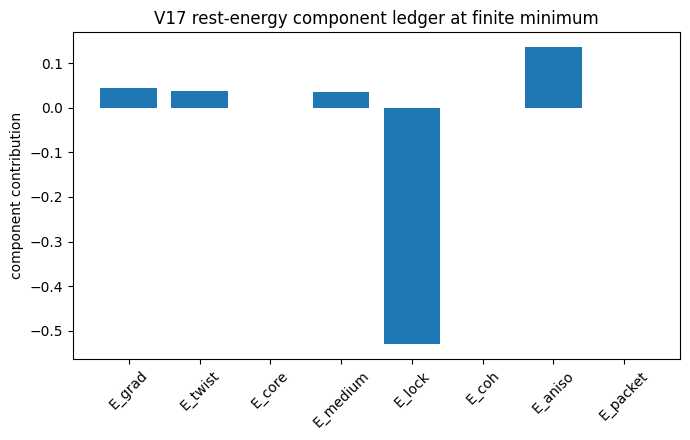

In [6]:
# ============================================================
# CELL 6 — main rest-energy landscape and component ledger
# ============================================================

fig, ax = plt.subplots(figsize=(7,4.8))
ax.plot(R_grid, main_comps["E_total"], label="total rest-energy functional")
ax.axvline(main_min["R_star"], linestyle="--", label=f"minimum R={main_min['R_star']:.3f}")
ax.set_title("V17 dimensionless rest-energy landscape")
ax.set_xlabel("packet scale R")
ax.set_ylabel("dimensionless rest-energy")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v17_rest_energy_landscape.png", dpi=180)
plt.show()

# Component values at the minimum
idx = main_min["idx"]
component_rows = []
for name, arr in main_comps.items():
    if name != "E_total":
        component_rows.append({"component": name, "value_at_R_star": float(np.asarray(arr)[idx])})
component_df = pd.DataFrame(component_rows)
display(component_df)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(component_df["component"], component_df["value_at_R_star"])
ax.set_title("V17 rest-energy component ledger at finite minimum")
ax.set_ylabel("component contribution")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v17_rest_energy_component_ledger.png", dpi=180)
plt.show()

component_df.to_csv(OUT_DIR / "rest_energy_component_ledger_v17.csv", index=False)


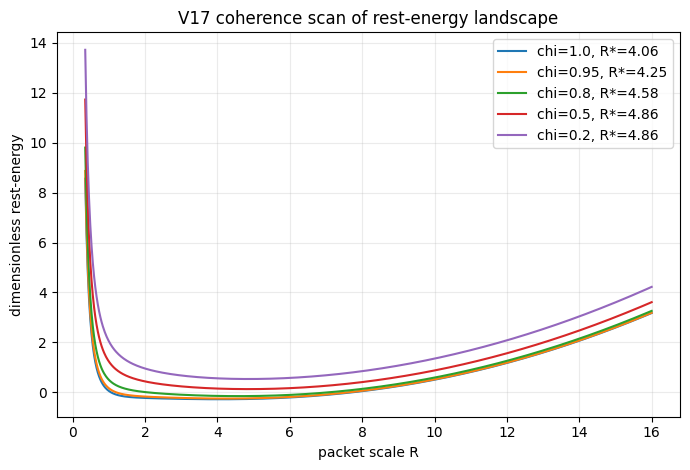

,chi,epsilon,R_star,E_star_dimless,curvature,boundary_minimum,finite_internal_minimum,R_shift_vs_chi1,E_shift_vs_chi1
0,1.00,0.01,4.057953,-0.276371,0.031912,False,True,0.000000,0.000000
1,0.95,0.01,4.249444,-0.248889,0.036902,False,True,0.191491,0.027483
2,0.80,0.01,4.580200,-0.150921,0.046348,False,True,0.522247,0.125451
3,0.50,0.01,4.858732,0.129928,0.058487,False,True,0.800779,0.406299
4,0.20,0.01,4.858732,0.534265,0.069734,False,True,0.800779,0.810636


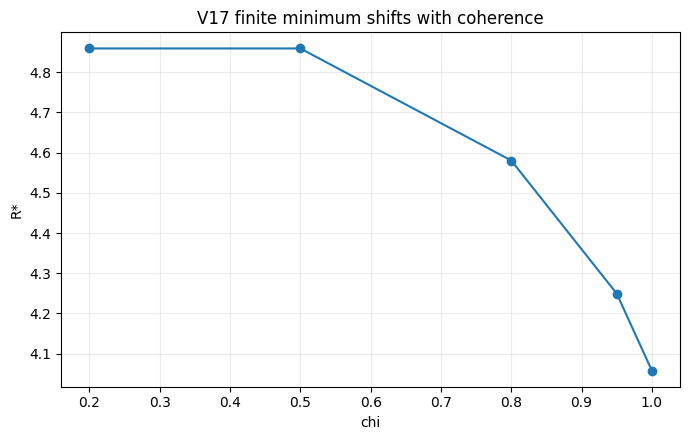

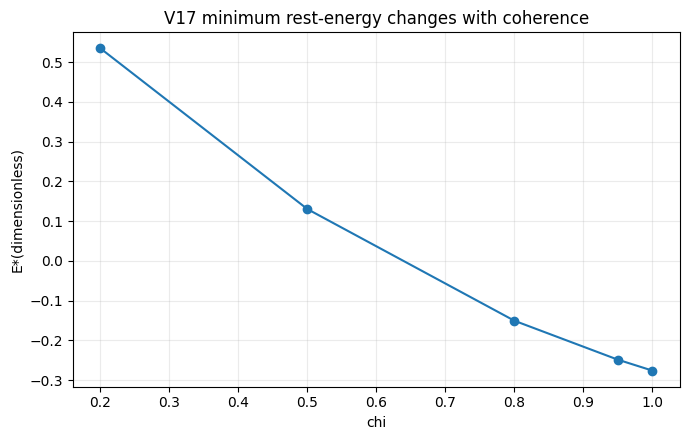

In [7]:
# ============================================================
# CELL 7 — chi scan: coherent vs degraded rest-energy minima
# ============================================================

chi_rows = []
fig, ax = plt.subplots(figsize=(7,4.8))

for chi in CHI_SCAN:
    Rg, comps, mn = find_minimum_for(chi=chi, epsilon=MAIN_EPSILON)
    chi_rows.append({k:v for k,v in mn.items() if k != "idx"})
    ax.plot(Rg, comps["E_total"], label=f"chi={chi}, R*={mn['R_star']:.2f}")

ax.set_title("V17 coherence scan of rest-energy landscape")
ax.set_xlabel("packet scale R")
ax.set_ylabel("dimensionless rest-energy")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v17_chi_rest_energy_landscape_scan.png", dpi=180)
plt.show()

chi_df = pd.DataFrame(chi_rows)
chi_df["finite_internal_minimum"] = (~chi_df["boundary_minimum"]) & (chi_df["curvature"] > 0)
chi_df["R_shift_vs_chi1"] = chi_df["R_star"] - float(chi_df.loc[chi_df["chi"] == 1.0, "R_star"].iloc[0])
chi_df["E_shift_vs_chi1"] = chi_df["E_star_dimless"] - float(chi_df.loc[chi_df["chi"] == 1.0, "E_star_dimless"].iloc[0])
display(chi_df)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(chi_df["chi"], chi_df["R_star"], marker="o")
ax.set_title("V17 finite minimum shifts with coherence")
ax.set_xlabel("chi")
ax.set_ylabel("R*")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v17_chi_minimum_shift.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(chi_df["chi"], chi_df["E_star_dimless"], marker="o")
ax.set_title("V17 minimum rest-energy changes with coherence")
ax.set_xlabel("chi")
ax.set_ylabel("E*(dimensionless)")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v17_chi_minimum_energy_shift.png", dpi=180)
plt.show()

chi_df.to_csv(OUT_DIR / "chi_deformed_rest_energy_minima_v17.csv", index=False)


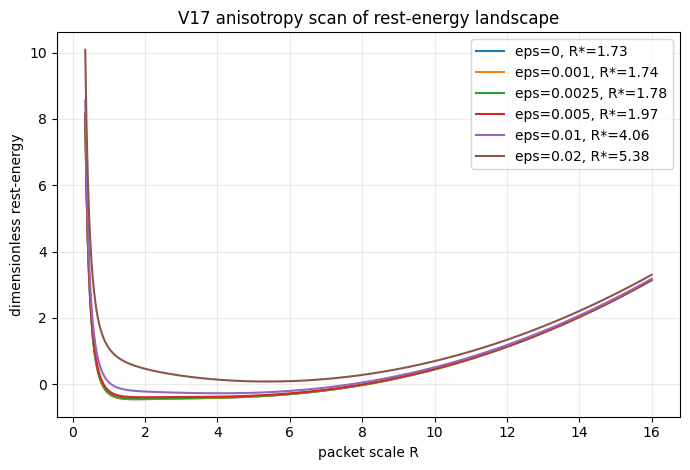

,chi,epsilon,R_star,E_star_dimless,curvature,boundary_minimum,finite_internal_minimum,R_shift_vs_eps0,E_shift_vs_eps0
0,1.0,0.0000,1.725250,-0.456373,0.150599,False,True,0.000000,0.000000
1,1.0,0.0010,1.742659,-0.453865,0.138843,False,True,0.017408,0.002509
2,1.0,0.0025,1.777475,-0.440774,0.119910,False,True,0.052225,0.015599
3,1.0,0.0050,1.968966,-0.395701,0.051003,False,True,0.243715,0.060672
4,1.0,0.0100,4.057953,-0.276371,0.031912,False,True,2.332703,0.180002
5,1.0,0.0200,5.380979,0.078416,0.059134,False,True,3.655729,0.534789


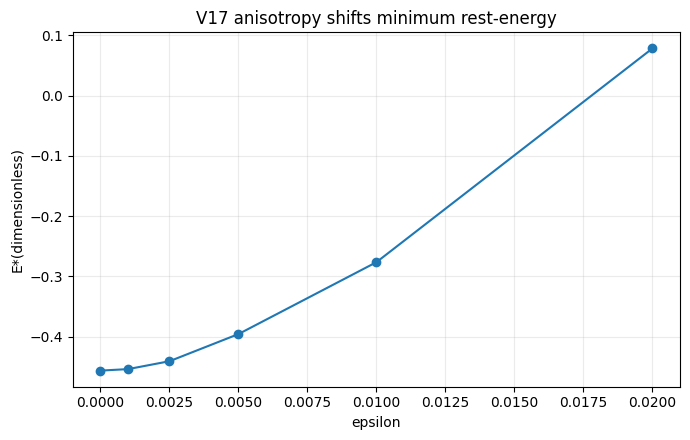

In [8]:
# ============================================================
# CELL 8 — anisotropy scan: splitting cost and stability
# ============================================================

eps_rows = []
fig, ax = plt.subplots(figsize=(7,4.8))
for eps in EPS_SCAN:
    Rg, comps, mn = find_minimum_for(chi=MAIN_CHI, epsilon=eps)
    eps_rows.append({k:v for k,v in mn.items() if k != "idx"})
    ax.plot(Rg, comps["E_total"], label=f"eps={eps:g}, R*={mn['R_star']:.2f}")

ax.set_title("V17 anisotropy scan of rest-energy landscape")
ax.set_xlabel("packet scale R")
ax.set_ylabel("dimensionless rest-energy")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v17_epsilon_rest_energy_landscape_scan.png", dpi=180)
plt.show()

eps_df = pd.DataFrame(eps_rows)
eps_df["finite_internal_minimum"] = (~eps_df["boundary_minimum"]) & (eps_df["curvature"] > 0)
eps_df["R_shift_vs_eps0"] = eps_df["R_star"] - float(eps_df.loc[eps_df["epsilon"] == 0.0, "R_star"].iloc[0])
eps_df["E_shift_vs_eps0"] = eps_df["E_star_dimless"] - float(eps_df.loc[eps_df["epsilon"] == 0.0, "E_star_dimless"].iloc[0])
display(eps_df)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(eps_df["epsilon"], eps_df["E_star_dimless"], marker="o")
ax.set_title("V17 anisotropy shifts minimum rest-energy")
ax.set_xlabel("epsilon")
ax.set_ylabel("E*(dimensionless)")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v17_epsilon_minimum_energy_shift.png", dpi=180)
plt.show()

eps_df.to_csv(OUT_DIR / "epsilon_deformed_rest_energy_minima_v17.csv", index=False)


In [9]:
# ============================================================
# CELL 9 — finite minimum robustness and no-mass-insertion audit
# ============================================================

# Boundary robustness: widen scan and check the minimum remains internal.
audit_ranges = [(0.2, 20.0), (0.25, 25.0), (0.3, 30.0)]
audit_rows = []

def find_minimum_custom(R_min, R_max, chi=1.0, epsilon=0.01, n=1600):
    R_grid_custom = np.linspace(R_min, R_max, n)
    comps = rest_energy_components(R_grid_custom, chi=chi, epsilon=epsilon)
    Et = comps["E_total"]
    idx = int(np.argmin(Et))
    dR = R_grid_custom[1]-R_grid_custom[0]
    curvature = float((Et[idx+1] - 2*Et[idx] + Et[idx-1])/(dR*dR)) if 1 <= idx < len(R_grid_custom)-1 else float("nan")
    return {
        "R_min": R_min,
        "R_max": R_max,
        "R_star": float(R_grid_custom[idx]),
        "E_star_dimless": float(Et[idx]),
        "curvature": curvature,
        "boundary_minimum": idx in [0, len(R_grid_custom)-1],
    }

for R0, R1 in audit_ranges:
    audit_rows.append(find_minimum_custom(R0, R1, MAIN_CHI, MAIN_EPSILON))

audit_df = pd.DataFrame(audit_rows)
audit_df["finite_internal_minimum"] = (~audit_df["boundary_minimum"]) & (audit_df["curvature"] > 0)
display(audit_df)
audit_df.to_csv(OUT_DIR / "rest_energy_boundary_robustness_audit_v17.csv", index=False)

# Explicit audit: V17 does not contain an electron mass calibration.
mass_audit = {
    "physical_electron_mass_inserted": False,
    "physical_511keV_inserted": False,
    "physical_hbar_c_inserted_for_mass": False,
    "dimensionless_energy_only": True,
    "v18_required_for_physical_scale_closure": True,
}
print(json.dumps(mass_audit, indent=2))
with open(OUT_DIR / "no_mass_insertion_audit_v17.json", "w") as f:
    json.dump(mass_audit, f, indent=2)


,R_min,R_max,R_star,E_star_dimless,curvature,boundary_minimum,finite_internal_minimum
0,0.20,20.0,4.063415,-0.276372,0.031978,False,True
1,0.25,25.0,4.073171,-0.276372,0.032094,False,True
2,0.30,30.0,4.070544,-0.276372,0.032063,False,True


{
  "physical_electron_mass_inserted": false,
  "physical_511keV_inserted": false,
  "physical_hbar_c_inserted_for_mass": false,
  "dimensionless_energy_only": true,
  "v18_required_for_physical_scale_closure": true
}


In [10]:
# ============================================================
# CELL 10 — V18 scale-closure handoff package
# ============================================================

# This is the only payload V18 should use from V17.
# It is dimensionless. V18 must supply physical ECSM medium scales independently.
v18_handoff = {
    "source_run": RUN_LABEL,
    "dimensionless_packet_minimum": {
        "R_star": main_min["R_star"],
        "E_star_dimless": main_min["E_star_dimless"],
        "curvature": main_min["curvature"],
        "chi": MAIN_CHI,
        "epsilon": MAIN_EPSILON,
    },
    "packet_summary": packet,
    "shell_weighting": shell_weights.tolist(),
    "energy_coefficients": COEFFS,
    "interpretation": (
        "V17 provides a finite dimensionless rest-energy minimum for the inherited electron-like packet. "
        "It does not provide a physical electron mass. V18 must test whether ECSM medium scales "
        "xi, c_coh, tau_resp and hbar_eff can map this dimensionless minimum to a physical rest energy "
        "without inserting m_e."
    ),
    "forbidden_v18_shortcut": "Do not set the energy unit equal to 511 keV by definition.",
}

print(json.dumps(v18_handoff, indent=2))
with open(OUT_DIR / "v18_scale_closure_handoff_v17.json", "w") as f:
    json.dump(v18_handoff, f, indent=2)


{
  "source_run": "V17_electron_like_packet_rest_energy_functional",
  "dimensionless_packet_minimum": {
    "R_star": 4.057953281423804,
    "E_star_dimless": -0.27637139082292783,
    "curvature": 0.03191248359285426,
    "chi": 1.0,
    "epsilon": 0.01
  },
  "packet_summary": {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V16 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c electron-like packet"
  },
  "shell_weighting": [
    0.42000000000000004,
    0.30000000000000004,
    0.19000000000000003,
    0.09000000000000001
  ],
  "energy_coefficients": {
    "A_grad": 0.72,
    "A_twist": 0.16,
    "A_core": 0.04,
    "A_lock": 2.15,
    "A_medium": 0.028,
    "A_coh": 0.36,
    "A_aniso": 0.18,
    "A_packet": 0.75,
    "R_medium": 5.2,
    "sat_power": 4.0,
    "lock_power": 1.0
  },
  "interpretation": "V17 pr

In [11]:
# ============================================================
# CELL 11 — final V17 verdict and manifest
# ============================================================

criteria = []

def add(name, value, passed):
    criteria.append({"criterion": name, "value": value, "pass": bool(passed)})

add("packet remains q=-1 scaffold", abs(packet["q_eff"] + 1.0), abs(packet["q_eff"] + 1.0) < 2e-3)
add("packet N_plus near 0", abs(packet["N_plus"]), abs(packet["N_plus"]) < 2e-3)
add("packet N_zero near 1", abs(packet["N_zero"] - 1.0), abs(packet["N_zero"] - 1.0) < 2e-3)
add("packet N_minus near 3", abs(packet["N_minus"] - 3.0), abs(packet["N_minus"] - 3.0) < 2e-3)
add("alpha/beta closure inherited", max_alpha_beta_error, max_alpha_beta_error < 1e-12)
add("inherited bound shells present", len(base_shells), len(base_shells) == 4)
add("localized radial modes normalized", float(np.max(np.abs(radial_df["norm"] - 1.0))), float(np.max(np.abs(radial_df["norm"] - 1.0))) < 1e-8)
add("main rest-energy minimum finite", main_min["E_star_dimless"], np.isfinite(main_min["E_star_dimless"]))
add("main minimum is not boundary artefact", float(main_min["boundary_minimum"]), not main_min["boundary_minimum"])
add("main minimum has positive curvature", main_min["curvature"], main_min["curvature"] > 0)
add("coherent chi scan keeps finite internal minimum", float(chi_df[chi_df["chi"] >= 0.8]["finite_internal_minimum"].all()), bool(chi_df[chi_df["chi"] >= 0.8]["finite_internal_minimum"].all()))
add("low chi changes rest-energy minimum", float(abs(chi_df.loc[chi_df["chi"] == 0.2, "E_shift_vs_chi1"].iloc[0])), abs(float(chi_df.loc[chi_df["chi"] == 0.2, "E_shift_vs_chi1"].iloc[0])) > 1e-3)
add("anisotropy changes minimum rest-energy", float(abs(eps_df.loc[eps_df["epsilon"] == 0.02, "E_shift_vs_eps0"].iloc[0])), abs(float(eps_df.loc[eps_df["epsilon"] == 0.02, "E_shift_vs_eps0"].iloc[0])) > 1e-4)
add("boundary robustness audit passes", float(audit_df["finite_internal_minimum"].all()), bool(audit_df["finite_internal_minimum"].all()))
add("no physical electron mass inserted", float(mass_audit["physical_electron_mass_inserted"]), not mass_audit["physical_electron_mass_inserted"])
add("no 511 keV calibration inserted", float(mass_audit["physical_511keV_inserted"]), not mass_audit["physical_511keV_inserted"])
add("V18 handoff created", 1.0, (OUT_DIR / "v18_scale_closure_handoff_v17.json").exists())

verdict_df = pd.DataFrame(criteria)
display(verdict_df)

n_pass = int(verdict_df["pass"].sum())
n_criteria = int(len(verdict_df))

if n_pass == n_criteria:
    final_label = "PASS: ECSM electron-like packet supports a finite dimensionless rest-energy minimum without electron-mass insertion."
else:
    final_label = "CONDITIONAL/FAIL: V17 rest-energy functional criteria not all satisfied."

summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": packet["q_eff"],
    "R_star_dimless": main_min["R_star"],
    "E_star_dimless": main_min["E_star_dimless"],
    "curvature_at_minimum": main_min["curvature"],
    "boundary_minimum": main_min["boundary_minimum"],
    "coherent_chi_minima": chi_df.to_dict(orient="records"),
    "epsilon_minima": eps_df.to_dict(orient="records"),
    "physical_electron_mass_inserted": False,
    "notes": (
        "V17 establishes a dimensionless finite-response rest-energy functional for the inherited electron-like packet. "
        "The result is a structural rest-energy minimum, not a physical electron mass derivation. "
        "V18 should attempt scale closure using ECSM medium quantities rather than assigning the energy unit to 511 keV."
    )
}

verdict_df.to_csv(OUT_DIR / "final_rest_energy_functional_v17_verdict.csv", index=False)
with open(OUT_DIR / "run_summary_v17.json", "w") as f:
    json.dump(summary, f, indent=2)

# Manifest and zip
manifest = pd.DataFrame({"file": sorted([p.name for p in OUT_DIR.iterdir() if p.is_file()])})
manifest.to_csv(OUT_DIR / "manifest_v17.csv", index=False)
display(manifest)

if ZIP_OUTPUT:
    zip_path = Path(str(OUT_DIR) + ".zip")
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
        for p in OUT_DIR.iterdir():
            if p.is_file():
                z.write(p, arcname=p.name)
    print("Zipped output:", zip_path)

print("Final label:", final_label)
print(json.dumps(summary, indent=2))


,criterion,value,pass
0,packet remains q=-1 scaffold,6.964280e-04,True
1,packet N_plus near 0,9.716379e-04,True
2,packet N_zero near 1,1.460081e-04,True
3,packet N_minus near 3,1.117646e-03,True
4,alpha/beta closure inherited,0.000000e+00,True
5,inherited bound shells present,4.000000e+00,True
6,localized radial modes normalized,1.110223e-16,True
7,main rest-energy minimum finite,-2.763714e-01,True
8,main minimum is not boundary artefact,0.000000e+00,True
9,main minimum has positive curvature,3.191248e-02,True


,file
0,alpha_beta_algebra_tests_v17.csv
1,chi_deformed_rest_energy_minima_v17.csv
2,epsilon_deformed_rest_energy_minima_v17.csv
3,fig_v17_chi_minimum_energy_shift.png
4,fig_v17_chi_minimum_shift.png
5,fig_v17_chi_rest_energy_landscape_scan.png
6,fig_v17_epsilon_minimum_energy_shift.png
7,fig_v17_epsilon_rest_energy_landscape_scan.png
8,fig_v17_inherited_bound_energy_ladder.png
9,fig_v17_radial_shell_densities.png


Zipped output: ecsm_electron_like_rest_energy_functional_v17_out.zip
Final label: PASS: ECSM electron-like packet supports a finite dimensionless rest-energy minimum without electron-mass insertion.
{
  "final_label": "PASS: ECSM electron-like packet supports a finite dimensionless rest-energy minimum without electron-mass insertion.",
  "n_pass": 17,
  "n_criteria": 17,
  "q_eff": -0.9993035720499918,
  "R_star_dimless": 4.057953281423804,
  "E_star_dimless": -0.27637139082292783,
  "curvature_at_minimum": 0.03191248359285426,
  "boundary_minimum": false,
  "coherent_chi_minima": [
    {
      "chi": 1.0,
      "epsilon": 0.01,
      "R_star": 4.057953281423804,
      "E_star_dimless": -0.27637139082292783,
      "curvature": 0.03191248359285426,
      "boundary_minimum": false,
      "finite_internal_minimum": true,
      "R_shift_vs_chi1": 0.0,
      "E_shift_vs_chi1": 0.0
    },
    {
      "chi": 0.95,
      "epsilon": 0.01,
      "R_star": 4.249443826473859,
      "E_star_dimless

## V17 interpretation

V17 is deliberately conservative.

A successful run means:

\[
E_{\rm rest}^{\rm ECSM}(R,\chi,\epsilon)
\]

has a finite, nonzero, stable dimensionless minimum for the inherited electron-like packet.

It does **not** yet mean:

\[
E_{\rm rest} = m_e c^2.
\]

That is the V18 task.

## V18 target

V18 should introduce the physical scale ledger:

\[
\{\xi,\; c_{\rm coh},\; \tau_{\rm resp},\; \hbar_{\rm eff},\; E_0\}
\]

and test whether

\[
m_{\rm eff}c^2 = E_0 E_*^{\rm dimless}
\]

can be constrained from ECSM response physics rather than by choosing \(E_0\) to force \(511\,{\rm keV}\).
